# Imports

In [49]:
import numpy as np
import torch 
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader

import sigkernel as ksig_pde
import sigkernel_ as ksig_disc

from generators.synthetic_generators import *
from generators.ESN import ESNGenerator, ESNAsTarget
from models.trainer_ESN_LBFGS import fit_ESN_MMD_LBFGS

from loss.loss import compute_mmd_loss

from utils.kernel_helpers import median_heuristic_sigma, tune_tau_coef_for_cv
from utils.analyse_controlled_experiments import *
from utils.analyse_results import *
from utils.data import *

%load_ext autoreload
%autoreload 2

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
dtype=torch.float64

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Generators

Initialize ESN and target ESN parameters.

In [ ]:
T = 100 # length of time series
N = 100  # number of samples (for target)
N_esn = 2000
target_rho = 0.7
xi_ma_theta = None 
d = 1   # dimension of time series
W_init_std = 0.1 # standard deviation for initializing the ESN output weight matrix W

target_type = "returns" # choice of target type: "returns", "log_returns", "sqrd_log_returns"

In [51]:
# Shared by both ESN
h, m, d = 500, 20, 1 # ESN hyperparameters: reservoir size, input dimension (\xi : randomness), output dimension
activation = "tanh"
quad_feedback = False # whether to include quadratic feedback in the ESN reservoir (to capture some nonlinearity and volatility clustering)
quad_gain = 0.0 # if set to 0.0 then no quadratic feedback
xi_scale = 1.0
eta_scale = 0.05

washout_len = h

A = 0.9 * torch.randn(h, h) / (h ** 0.5) # ESN reservoir weight matrix
C = torch.randn(h, m) / (m ** 0.5) # ESN input weight matrix

Create trainable ESN and target ESN instances.

In [52]:
p = 2   # AR order
q = 0   # MA order
phi = None # AR coefficients
theta = [0.5, 0.24] # MA coefficients
burnin = 50 # number of initial samples to discard to mitigate initialization effects

target_generator = ARMA(T=T, p=p, q=q, phi=phi, theta=theta, d=d, burnin=burnin)

In [53]:
# ESN estimator
esn = ESNGenerator(A, C, out_dim=d, xi_scale=xi_scale, 
                   eta_scale=eta_scale, activation=activation, 
                   target_rho=target_rho, xi_ma_theta=xi_ma_theta, 
                   quad_feedback=quad_feedback, quad_gain=quad_gain,
                   W_init=None, washout_len=washout_len) # if random W
                #  W_init=W_fixed) # if want to start from correct W

# Kernels

In [54]:
with torch.no_grad():
    Z_target_raw = target_generator.generate(T=T, N=N).to(device=device, dtype=dtype)
    Z_esn_raw = esn(T=T, N=N_esn).to(device=device, dtype=dtype)

# Apply the selected target transformation
eps = 1e-8

if target_type == "returns":
    Z_target = Z_target_raw
    Z_esn = Z_esn_raw
elif target_type == "log_returns":
    Z_target = torch.log1p(Z_target_raw) # this doesnt make sense with real returns (I need percentage returns)
    Z_esn = torch.log1p(Z_esn_raw)
elif target_type == "sqrd_log_returns": # this doesnt make sense with real returns (I need percentage returns)
    log_r = torch.log1p(Z_target_raw)
    Z_target = log_r ** 2
    Z_esn = torch.log1p(Z_esn_raw) ** 2
elif target_type == "log_sqrd_returns":
    Z_target = torch.log(Z_target_raw ** 2 + eps)
    Z_esn = torch.log(Z_esn_raw ** 2 + eps)

print(f"Generated data shapes: Z_target: {Z_target.shape}, Z_esn: {Z_esn.shape}")
_median_heuristic_sigma = median_heuristic_sigma(Z_target, Z_esn)
print(f"Median heuristic sigma: {_median_heuristic_sigma:.6f}")

Generated data shapes: Z_target: torch.Size([100, 100, 1]), Z_esn: torch.Size([2000, 100, 1])
Median heuristic sigma: 22.158024


In [55]:
# Define the discretized signature kernel
static_kernel_type    = 'rbf' # type of static kernel to use - rbf, rbfmix, rq, rqmix, rqlinear for
n_levels              = 10 # number of levels in the truncated signature kernel
disc_sig_kernel_sigma = _median_heuristic_sigma # bandwidth parameter for the static kernel

sig_disc_kernel = ksig_disc.kernels.get_discretized_signature_kernel(**{'static_kernel_type': static_kernel_type, 'n_levels': n_levels, 'kernel_sigma': disc_sig_kernel_sigma})

#---------------------------------
# Define the pde signature kernel
pde_sig_sigma = _median_heuristic_sigma # bandwidth parameter for the static kernel
static_kernel = ksig_pde.RBFKernel(sigma=pde_sig_sigma) # define static kernel

sig_pde_kernel = ksig_pde.SigKernel(static_kernel, dyadic_order=0)

#---------------------------------
# Define static kernel
static_sigma = _median_heuristic_sigma # bandwidth parameter for the static kernel

rbf_kernel = ksig_disc.kernels.RBFKernel(sigma=static_sigma)

#---------------------------------
# # Volterra kernel
# ld_coef = 0.7
# tau_best, cv_best, spec_best = tune_tau_coef_for_cv(X, ld_coef=ld_coef)
# tau_coef = tau_best
# volterra_kernel = ksig_disc.kernels.VolterraKernel(ld_coef=ld_coef, tau_coef=tau_coef)
# volterra_kernel.fit(X) # fitting is needed to compute lambda, tau and the normalization constant
# print(f"Best tau: {tau_best}, CV: {cv_best}")

## Choose kernel

Choose one kernel

In [56]:
# kernel = sig_disc_kernel      # discretized signature kernel
# kernel = sig_pde_kernel        # pde signature kernel
kernel = rbf_kernel           # static kernel
# kernel = volterra_kernel      # volterra kernel

Run initial MMD to check and as a baseline

In [57]:
if "sig" in kernel.__class__.__name__.lower() or "volt" in kernel.__class__.__name__.lower():
    kernel_mode = "sequential"
else:
    kernel_mode = "static"

print(f"Using kernel: {kernel.__class__.__name__} with kernel mode: {kernel_mode}")

# initial mmd:
initial_mmd = compute_mmd_loss(kernel, Z_target, Z_esn) if kernel_mode == "sequential" else compute_mmd_loss(kernel, Z_target.reshape(Z_target.shape[0], -1), Z_esn.reshape(Z_esn.shape[0], -1))
print(f"Initial MMD with {kernel.__class__.__name__} kernel: {initial_mmd:.6f}")

Using kernel: RBFKernel with kernel mode: static
Initial MMD with RBFKernel kernel: 0.048830


# Baseline MMD

In [58]:
# iterations = 1000
# N_small = N
# N_large = N_esn
# baseline_mmd = compute_baseline_mmd(target_generator,kernel,noise,iterations,N_small,N_large,kernel_mode,dtype,device, target_type)
# print("Baseline MMD:", baseline_mmd)

# Statistical Analysis Before Fitting

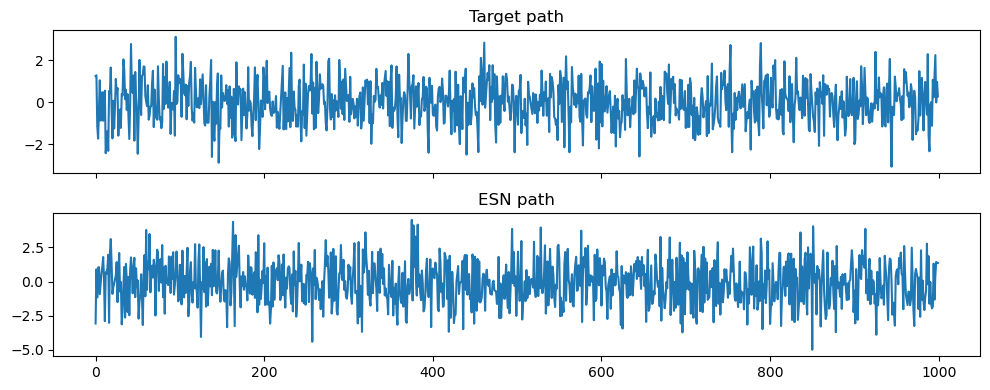

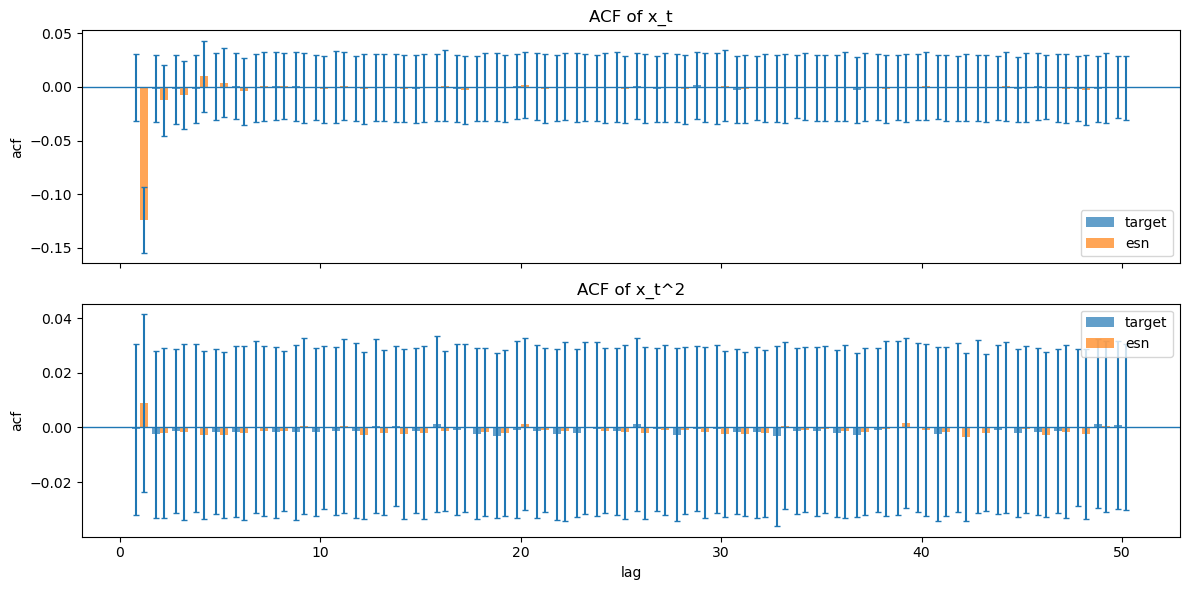

In [59]:
# run ACF analysis (plots + curves)
N_acf = 1000
T_acf = 1000
lag_acf = 50
acf_out = acf_analysis(
    esn,
    target_generator=target_generator,
    N=N_acf,
    T=T_acf,
    lag=lag_acf,
    component=0,
    device=device,
    dtype=dtype,
)

In [60]:
with torch.no_grad():
    Z_esn = esn(T=T, N=N_esn).to(device=device, dtype=dtype)

res = acf_two_sample_test(
    Z_target,
    Z_esn,
    lag=lag_acf,
    normalize=True,
    seed=0,
)

res_sq = acf_two_sample_test(
    Z_target,
    Z_esn,
    lag=lag_acf,
    use_squared=True,
    normalize=True,
)

res_joint = acf_two_sample_test(
    Z_target,
    Z_esn,
    lag=lag_acf,
    joint=True,
    normalize=True,
)

print("\nACF two-sample test summary")
print(f"ACF(joint) -> T_obs: {res_joint['T_obs']:.6f}, p_value: {res_joint['p_value']:.6f}")
print(f"ACF(x^2)   -> T_obs: {res_sq['T_obs']:.6f}, p_value: {res_sq['p_value']:.6f}")
print(f"ACF(x)     -> T_obs: {res['T_obs']:.6f}, p_value: {res['p_value']:.6f}")



ACF two-sample test summary
ACF(joint) -> T_obs: 3.131772, p_value: 0.000000
ACF(x^2)   -> T_obs: 0.500439, p_value: 0.999000
ACF(x)     -> T_obs: 2.631333, p_value: 0.000000


# Fit ESN

In [61]:
print(f"Using kernel: {kernel.__class__.__name__} with kernel mode: {kernel_mode}")
results = fit_ESN_MMD_LBFGS(esn = esn, 
                            Z_target = Z_target,
                            kernel = kernel, 
                            kernel_mode = kernel_mode,
                            N_model= N_esn, 
                            lead_lag=False,
                            lags=0,
                            max_iter = 1000, 
                            lr=0.1, 
                            force_float64=True,
                            verbose=True,
                            target_type=target_type
)


Using kernel: RBFKernel with kernel mode: static
MMD initial: 0.05040430036620499
MMD final: 0.0007867774259256465


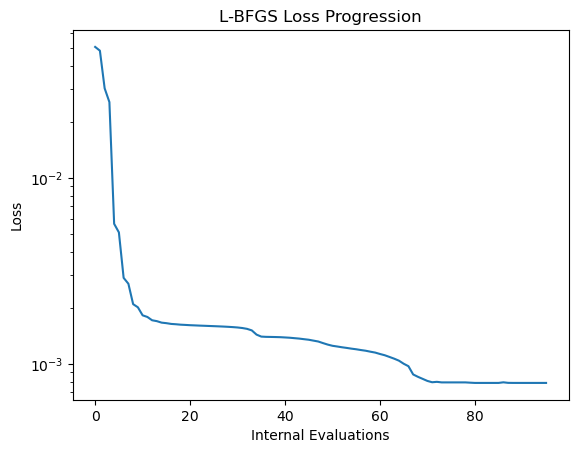

In [62]:
loss_history = results['loss_history']
plt.plot(loss_history)
plt.xlabel('Internal Evaluations')
plt.ylabel('Loss')
plt.title('L-BFGS Loss Progression')
plt.yscale('log') # Useful if loss drops several orders of magnitude
plt.show()

# Statistical Analysis After Fitting

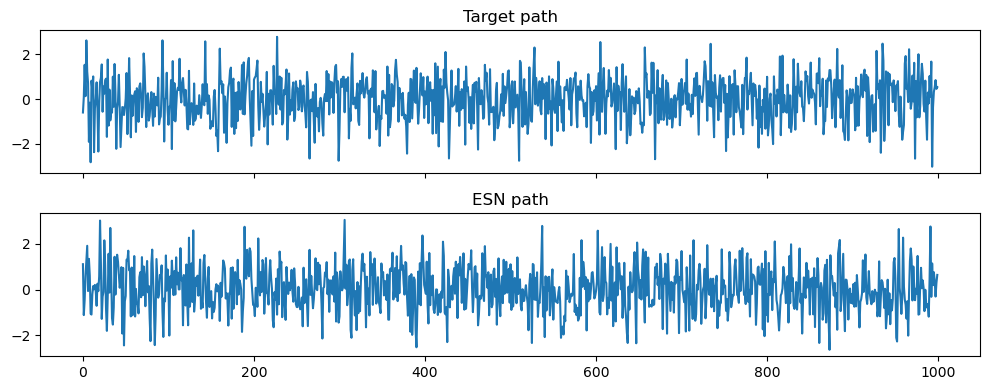

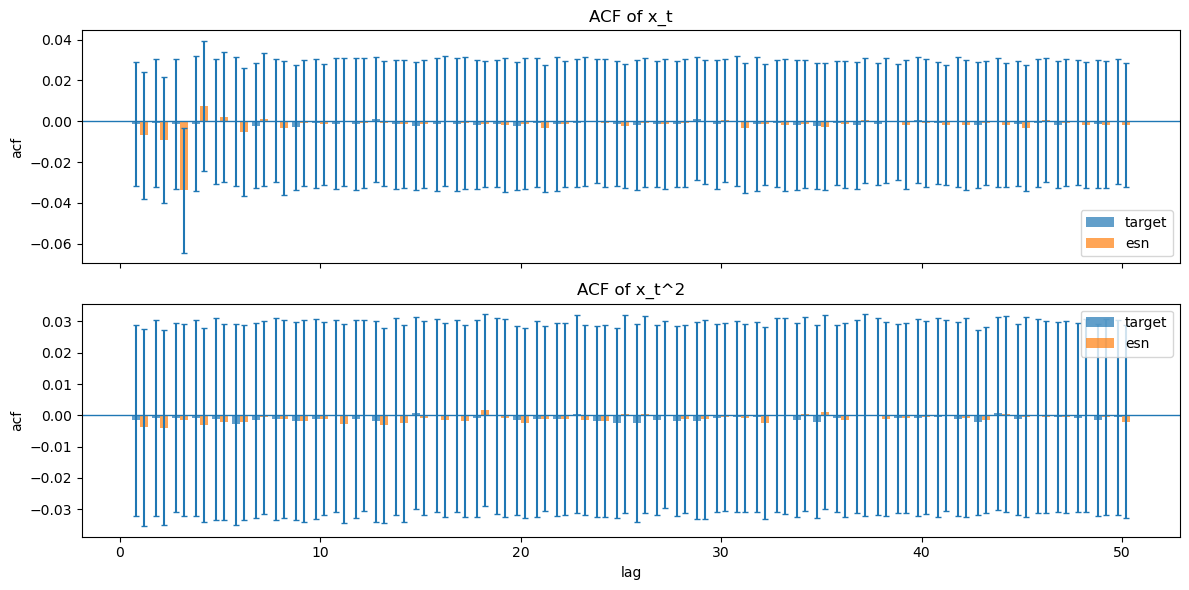

In [63]:
# run ACF analysis (plots + curves)
N_acf = 1000
T_acf = 1000
lag_acf = 50
acf_out = acf_analysis(
    esn,
    target_generator=target_generator,
    N=N_acf,
    T=T_acf,
    lag=lag_acf,
    component=0,
    device=device,
    dtype=dtype,
)

In [64]:
with torch.no_grad():
    Z_esn = esn(T=T, N=N_esn).to(device=device, dtype=dtype)

res = acf_two_sample_test(
    Z_target_raw,
    Z_esn,
    lag=lag_acf,
    normalize=True,
    seed=0,
)

res_sq = acf_two_sample_test(
    Z_target_raw,
    Z_esn,
    lag=lag_acf,
    use_squared=True,
    normalize=True,
)

res_joint = acf_two_sample_test(
    Z_target_raw,
    Z_esn,
    lag=lag_acf,
    joint=True,
    normalize=True,
)

print("\nACF two-sample test summary")
print(f"ACF(x)     -> T_obs: {res['T_obs']:.6f}, p_value: {res['p_value']:.6f}")
print(f"ACF(x^2)   -> T_obs: {res_sq['T_obs']:.6f}, p_value: {res_sq['p_value']:.6f}")
print(f"ACF(joint) -> T_obs: {res_joint['T_obs']:.6f}, p_value: {res_joint['p_value']:.6f}")



ACF two-sample test summary
ACF(x)     -> T_obs: 0.707170, p_value: 0.918000
ACF(x^2)   -> T_obs: 0.534555, p_value: 0.999000
ACF(joint) -> T_obs: 1.241725, p_value: 0.998000


In [65]:
# target
phis_tgt, thetas_tgt = fit_arma_on_paths(Z_target[...,0], p=0, q=2)

# esn
with torch.no_grad():
    Z_esn = esn(T=T, N=N_esn).cpu().numpy()

phis_esn, thetas_esn = fit_arma_on_paths(Z_esn[...,0], p=0, q=2)

# compare
print("target:", summarize_params(phis_tgt, thetas_tgt))
print("esn:", summarize_params(phis_esn, thetas_esn))

target: {'theta_mean': array([0.02924677, 0.00828749]), 'theta_std': array([0.10817296, 0.12008346])}
esn: {'theta_mean': array([-0.00969932, -0.01099318]), 'theta_std': array([0.10682226, 0.10634402])}
